In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# !pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# IMPORT FUNCTIONS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, make_scorer

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import time
from sklearn.metrics import confusion_matrix

In [ ]:
from xgboost import XGBClassifier

# CONFIGURATIONS

In [ ]:
TARGET_COL = "class"
UNNECESSARY_COLS = []
CATEGORICAL_FILL_MODE = "mode"
NUMERIC_FILL_VALUES = {}
OUTLIER_FILTER = {}
GAUSSIAN_LIKE = ['radius1', 'texture1', 'perimeter1', 'smoothness1', 'symmetry1', 'texture3', 'smoothness3']

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

y = y.squeeze()
if not np.issubdtype(y.dtype, np.number):
    le = LabelEncoder()
    y = pd.Series(le.fit_transform(y), name="diagnosis")

# Rebuild a single DataFrame to keep your original flow intact
df = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True).rename(TARGET_COL)], axis=1)

option = int(input(
    "Choose the model:\n"
    "1. Decision Tree\n"
    "2. AdaBoost\n"
    "3. Gradient Boosting\n"
    "4. XGBoost\n"
    "5. Random Forest\n"
    "6. Stacking (SVM + Naive Bayes + Decision Tree)\n"
))

stack_estimators = [
    ("svm", make_pipeline(StandardScaler(), SVC(probability=True, kernel="rbf"))),
    ("nb", GaussianNB()),
    ("dt", DecisionTreeClassifier(random_state=42)),
]

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

model_param_map = {
    1: {
        "model": DecisionTreeClassifier(random_state=42),
        "param_grid": {
            "criterion": ["gini", "entropy", "log_loss"],
            "max_depth": [None, 3, 5, 7],
            # "min_samples_split": [2, 5, 10],
            # "min_samples_leaf": [1, 2, 4]
        }
    },
    2: {
        "model": AdaBoostClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.5, 1.0, 1.5],
            # "base_estimator": [
            #     DecisionTreeClassifier(max_depth=1, random_state=42),
            #     DecisionTreeClassifier(max_depth=3, random_state=42)
            # ]
        }
    },
    3: {
        "model": GradientBoostingClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [2, 3],
            # "subsample": [0.8, 1.0]
        }
    },
    4: {
        "model": xgb_model,
        "param_grid": {
            "n_estimators": [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5],
            "gamma": [0, 1],
            # "subsample": [0.8, 1.0],
            # "colsample_bytree": [0.8, 1.0]
        }
    },
    5: {
        "model": RandomForestClassifier(random_state=42),
        "param_grid": {
            "n_estimators": [100, 200],
            "criterion": ["gini", "entropy", "log_loss"],
            "max_depth": [None, 5, 10],
            # "max_features": ["sqrt", "log2", None],
            # "min_samples_split": [2, 5]
        }
    },
    6: {
        "model": StackingClassifier(
            estimators=stack_estimators,
            final_estimator=LogisticRegression(max_iter=1000, random_state=42),
            n_jobs=-1
        ),
        "param_grid": {
            "svm__svc__C": [0.1, 1, 10],
            "dt__max_depth": [None, 3, 5, 10],
            "final_estimator__C": [0.1, 1, 10]
        }
    },

    7: {
        "model": StackingClassifier(
            estimators=[
                ("svm", make_pipeline(StandardScaler(), SVC(probability=True, kernel="rbf"))),
                ("nb", GaussianNB()),
                ("dt", DecisionTreeClassifier(random_state=42))
            ],
            final_estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
            n_jobs=-1
        ),
        "param_grid": {
            "svm__svc__C": [0.1, 1, 10],
            "dt__max_depth": [None, 3, 5, 10],
            "final_estimator__n_estimators": [50, 100, 200],
            "final_estimator__max_depth": [None, 5, 10]
        }
    },

    8: {
        "model": StackingClassifier(
            estimators=[
                ("svm", make_pipeline(StandardScaler(), SVC(probability=True, kernel="rbf"))),
                ("dt", DecisionTreeClassifier(random_state=42)),
                ("knn", KNeighborsClassifier())
            ],
            final_estimator=LogisticRegression(max_iter=1000, random_state=42),
            n_jobs=-1
        ),
        "param_grid": {
            "svm__svc__C": [0.1, 1, 10],
            "dt__max_depth": [None, 3, 5, 10],
            "knn__n_neighbors": [3, 5, 7],
            "final_estimator__C": [0.1, 1, 10]
        }
    }
}

if option not in model_param_map:
    raise ValueError("Invalid option selected!")

model_config = model_param_map[option]
base_model = model_config["model"]
param_grid = model_config["param_grid"]

Choose the model:
1. Decision Tree
2. AdaBoost
3. Gradient Boosting
4. XGBoost
5. Random Forest
6. Stacking (SVM + Naive Bayes + Decision Tree)
4


In [ ]:
df

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,1
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,1
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,1
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,1


# LOAD DATA

# REMOVE UNWANTED COLUMNS

In [ ]:
# if UNNECESSARY_COLS:
#     df.drop(columns=[col for col in UNNECESSARY_COLS if col in df.columns], inplace=True)

# FILL MISSING VALUES

In [ ]:
for col in df.columns:
  count = df[col].isna().sum()
  print(f"{col} -> {count} missing values")

# if NUMERIC_FILL_VALUES:
#   for col, val in NUMERIC_FILL_VALUES.items():
#       if col in df.columns:
#           if val == 'median':
#               df[col] = df[col].fillna(df[col].median())
#           elif val == 'mean':
#               df[col] = df[col].fillna(df[col].mean())
#           else:
#               df[col] = df[col].fillna(val)

# for col in df.select_dtypes(include=['int64', 'float64']):
#   if col in df.columns:
#     df[col] = df[col].fillna(df[col].median())

# for col in df.select_dtypes(include='object').columns:
#     if CATEGORICAL_FILL_MODE == "mode":
#         df[col] = df[col].fillna(df[col].mode()[0])
#     else:
#         df[col] = df[col].fillna("Unknown")

# df = df[~df[TARGET_COL].isna()]

radius1 -> 0 missing values
texture1 -> 0 missing values
perimeter1 -> 0 missing values
area1 -> 0 missing values
smoothness1 -> 0 missing values
compactness1 -> 0 missing values
concavity1 -> 0 missing values
concave_points1 -> 0 missing values
symmetry1 -> 0 missing values
fractal_dimension1 -> 0 missing values
radius2 -> 0 missing values
texture2 -> 0 missing values
perimeter2 -> 0 missing values
area2 -> 0 missing values
smoothness2 -> 0 missing values
compactness2 -> 0 missing values
concavity2 -> 0 missing values
concave_points2 -> 0 missing values
symmetry2 -> 0 missing values
fractal_dimension2 -> 0 missing values
radius3 -> 0 missing values
texture3 -> 0 missing values
perimeter3 -> 0 missing values
area3 -> 0 missing values
smoothness3 -> 0 missing values
compactness3 -> 0 missing values
concavity3 -> 0 missing values
concave_points3 -> 0 missing values
symmetry3 -> 0 missing values
fractal_dimension3 -> 0 missing values
class -> 0 missing values


# CHECK AND REMOVE OUTLIERS

In [ ]:
# for col in df.select_dtypes(include=['int64', 'float64']).columns:
#     sns.histplot(df[col], kde=True)
#     plt.title(f"Distribution of {col}")
#     plt.show()

In [ ]:
# for col, threshold in OUTLIER_FILTER.items():
#     df = df[df[col] < threshold]

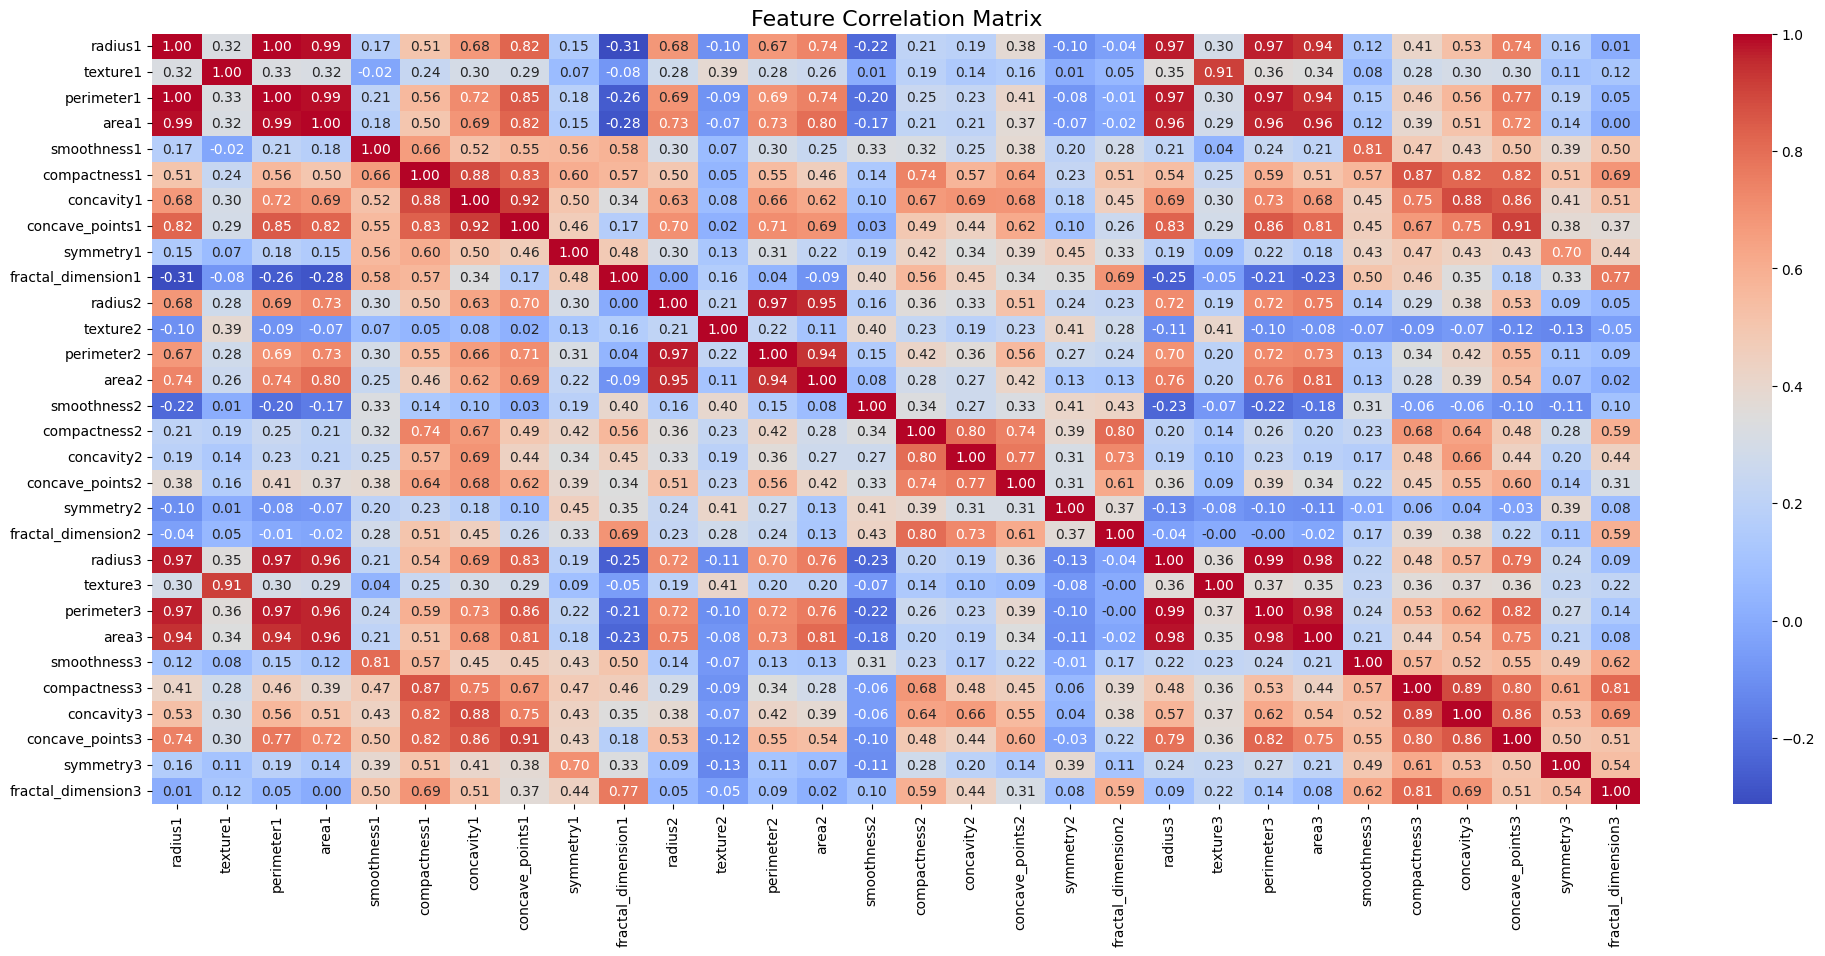

In [ ]:
corr = df.drop(columns=["class"]).corr()

# Plot heatmap
plt.figure(figsize=(24, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

# ENCODE CATEGORICAL DATA

In [ ]:
# label_encoders = {}
# for col in df.select_dtypes(include='object').columns:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     label_encoders[col] = le

# SPLITTING TO FEATURES AND TARGETS

In [ ]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# STANDARDIZE CONTINUOUS DATA

In [ ]:
# from sklearn.preprocessing import StandardScaler, MinMaxScaler
# from scipy.stats import normaltest
# import numpy as np

# if option == 6: # Stacking model uses SVM and scaling is required
#     numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
#     features_to_scale = [col for col in numerical_cols if col != TARGET_COL]

#     scaler = StandardScaler()
#     X_train[GAUSSIAN_LIKE] = scaler.fit_transform(X_train[GAUSSIAN_LIKE])

#     non_gaussian = [col for col in features_to_scale if col not in GAUSSIAN_LIKE]
#     normalizer = MinMaxScaler()
#     df[non_gaussian] = normalizer.fit_transform(df[non_gaussian])

# CROSS VALIDATION

In [ ]:
# Step 3: Use GridSearchCV to find best hyperparameters
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1": make_scorer(f1_score, zero_division=0)
}

grid = GridSearchCV(estimator=base_model,
                    param_grid=param_grid,
                    scoring=scoring,
                    refit="accuracy",
                    cv=skf,
                    n_jobs=-1)
grid.fit(X_val, y_val)

print("✅ Best hyperparameters:", grid.best_params_)

best_model = grid.best_estimator_

# Step 4: Cross-validation metrics using best model
cv_metrics = {
    "Fold": [], "Accuracy": [], "Precision": [], "Recall": [], "F1": []
}

fold = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_model.fit(X_train_fold, y_train_fold)
    y_pred = best_model.predict(X_val_fold)

    cv_metrics["Fold"].append(f"Fold {fold}")
    cv_metrics["Accuracy"].append(accuracy_score(y_val_fold, y_pred))
    cv_metrics["Precision"].append(precision_score(y_val_fold, y_pred, zero_division=0))
    cv_metrics["Recall"].append(recall_score(y_val_fold, y_pred))
    cv_metrics["F1"].append(f1_score(y_val_fold, y_pred))
    fold += 1

# Add average row
cv_metrics["Fold"].append("Average")
for metric in ["Accuracy", "Precision", "Recall", "F1"]:
    cv_metrics[metric].append(np.mean(cv_metrics[metric]))

print("\n📋 Cross-Validation Metrics:")
print(pd.DataFrame(cv_metrics))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:12:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:12:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:12:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Best hyperparameters: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:12:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:12:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:12:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📋 Cross-Validation Metrics:
      Fold  Accuracy  Precision    Recall        F1
0   Fold 1  0.950000   1.000000  0.866667  0.928571
1   Fold 2  0.925000   0.928571  0.866667  0.896552
2   Fold 3  0.950000   0.933333  0.933333  0.933333
3   Fold 4  1.000000   1.000000  1.000000  1.000000
4   Fold 5  0.871795   0.800000  0.857143  0.827586
5  Average  0.939359   0.932381  0.904762  0.917209


In [ ]:
results = pd.DataFrame(grid.cv_results_)

metrics_table = results[
    ["params", "mean_test_accuracy", "std_test_accuracy",
     "mean_test_f1", "std_test_f1", "rank_test_accuracy"]
]

metrics_table

,params,mean_test_accuracy,std_test_accuracy,mean_test_f1,std_test_f1,rank_test_accuracy
0,"{'gamma': 0, 'learning_rate': 0.05, 'max_depth...",0.954615,0.024973,0.938821,0.034522,1
1,"{'gamma': 0, 'learning_rate': 0.05, 'max_depth...",0.949487,0.032440,0.932274,0.044966,13
2,"{'gamma': 0, 'learning_rate': 0.05, 'max_depth...",0.954615,0.024973,0.938821,0.034522,1
3,"{'gamma': 0, 'learning_rate': 0.05, 'max_depth...",0.944487,0.037379,0.924962,0.051581,15
4,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.949487,0.032440,0.932274,0.044966,13
5,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.944487,0.029953,0.926226,0.041704,16
6,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.954615,0.024973,0.938623,0.035059,1
7,"{'gamma': 0, 'learning_rate': 0.1, 'max_depth'...",0.954615,0.024973,0.938623,0.035059,1
8,"{'gamma': 1, 'learning_rate': 0.05, 'max_depth...",0.954615,0.024973,0.938821,0.034522,1
9,"{'gamma': 1, 'learning_rate': 0.05, 'max_depth...",0.954615,0.024973,0.938821,0.034522,1


# Validation

In [ ]:
# Best model from GridSearchCV
best_model = grid.best_estimator_

# Measure training time
start_time = time.time()
best_model.fit(X_train, y_train)
training_duration = time.time() - start_time
print(f"\n⏱️ Model Training Time: {training_duration:.2f} seconds\n")


⏱️ Model Training Time: 0.09 seconds



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:12:48] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
def evaluate_classification(name, y_true, y_pred):
    print(f"\n📊 {name} Metrics:")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_true, y_pred):.4f}")

    if name == "Test":
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'{name} - Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()


📊 Train Metrics:
  Accuracy : 0.9950
  Precision: 1.0000
  Recall   : 0.9865
  F1-Score : 0.9932

📊 Validation Metrics:
  Accuracy : 0.9497
  Precision: 0.9444
  Recall   : 0.9189
  F1-Score : 0.9315

📊 Test Metrics:
  Accuracy : 0.9532
  Precision: 0.9516
  Recall   : 0.9219
  F1-Score : 0.9365


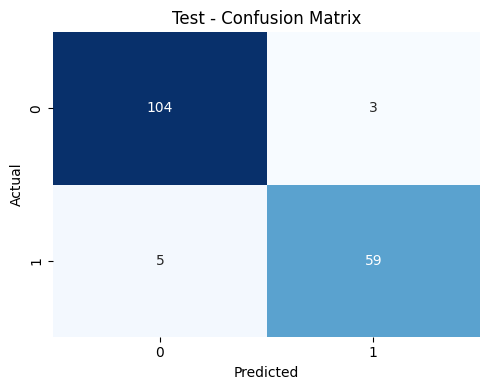

/tmp/ipython-input-566432610.py:28: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


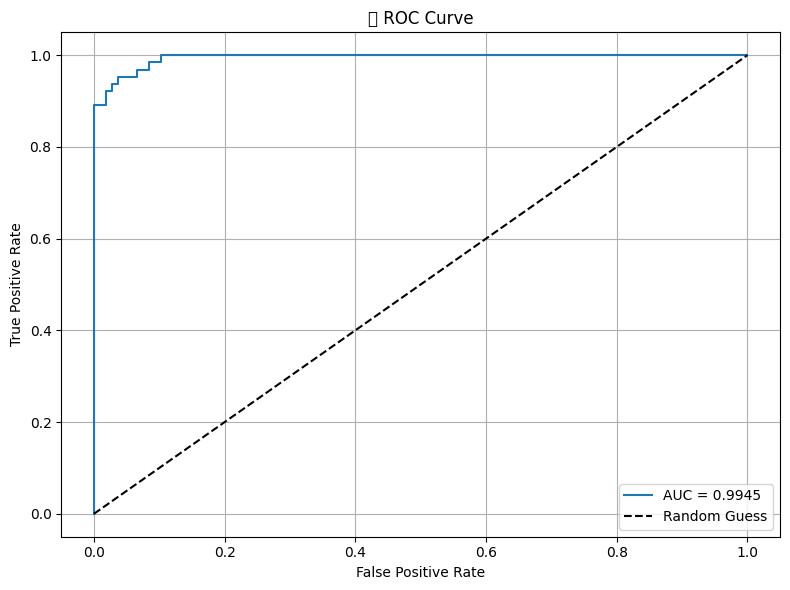

In [ ]:
for name, (X_split, y_split) in zip(["Train", "Validation", "Test"], [(X_train, y_train), (X_val, y_val), (X_test, y_test)]):

    y_pred = best_model.predict(X_split)
    evaluate_classification(name, y_split, y_pred)

    if name == "Test":

        if hasattr(best_model, "predict_proba"):
            y_probs = best_model.predict_proba(X_split)[:, 1]
        elif hasattr(best_model, "decision_function"):
            y_probs = best_model.decision_function(X_split)
        else:
            print("Model does not support ROC plotting.")
            continue

        # Plot ROC Curve
        fpr, tpr, _ = roc_curve(y_split, y_probs)
        auc_score = roc_auc_score(y_split, y_probs)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
        plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("🔍 ROC Curve")
        plt.legend(loc="lower right")
        plt.grid()
        plt.tight_layout()
        plt.show()